In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt

# Common Period

In [2]:
iyear = 1981
fyear = 2015
models = ['APHRO','CHIRPS','CRU','ERA5','GPCP','HARv2']
domains = ['HMA','HK','SL','TP','CH','SEH']

# TP timeseries DATASETS & DOMAINS

## Annual

In [3]:
tp_datasets = {}
stats_datasets = {}

path = '/bettik/PROJECTS/pr-regional-climate/bricej/results/timeseries/'

for model in models:
    tp_datasets[model] = {}
    stats_datasets[model] = {}
    for domain in domains:
        tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1981-2015_{model}.csv')
        stats_datasets[model][domain] = pd.read_csv(path + f'stats_tp_annual_{domain}_1981-2015_{model}.csv')

,HMA,HK,SL,TP,CH,SEH
APHRO,1.70,8.24,1.88,0.87,-2.26,-1.15
CHIRPS,1.28,1.82,-1.70,1.59,0.67,1.77
CRU,-0.06,0.90,-0.71,0.41,-2.47,-0.88
ERA5,-0.85,-1.44,-0.96,1.04,2.67,-7.12
GPCP,-0.01,1.26,-1.25,0.87,-3.58,-1.74
HARv2,-0.15,-0.87,-1.78,1.02,2.72,-4.35


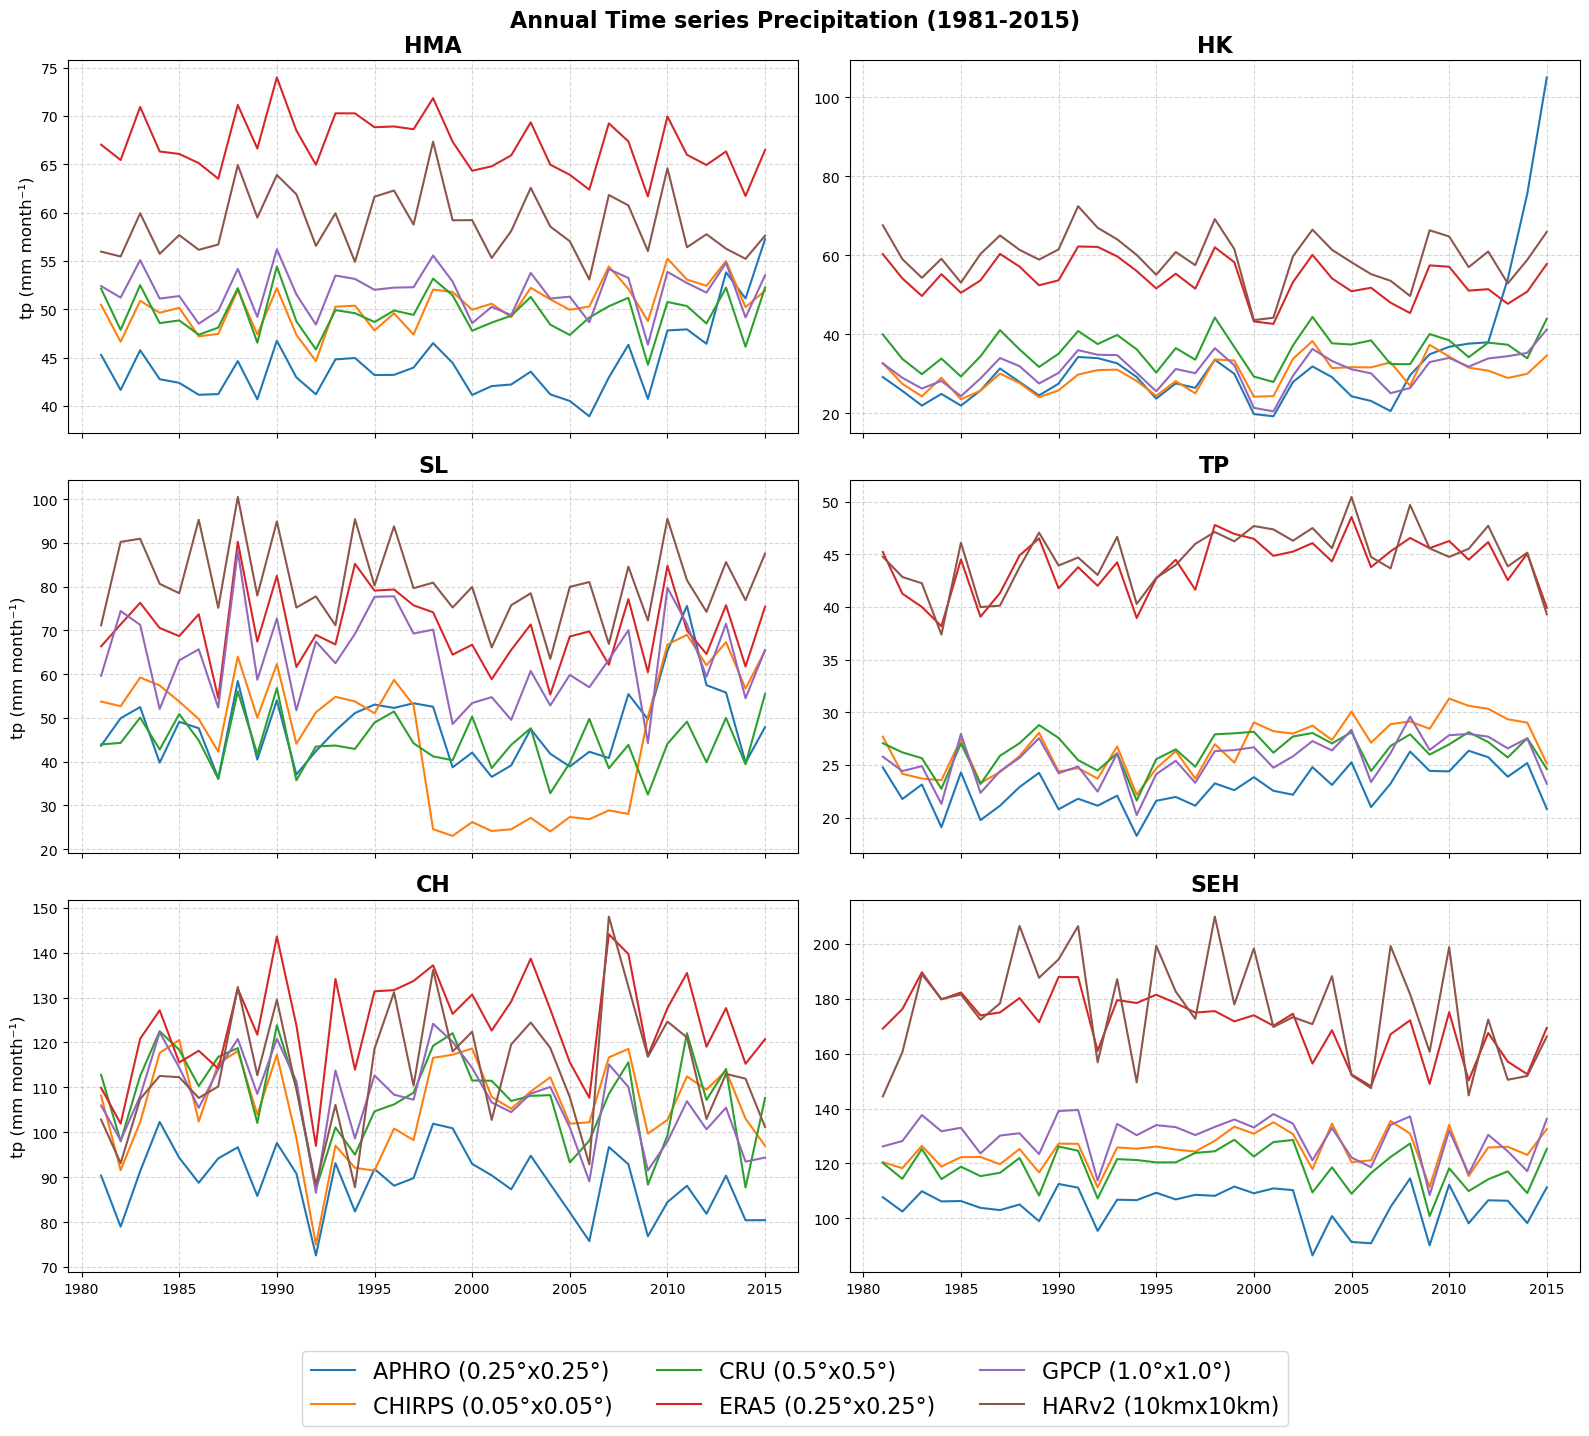

In [4]:
resolutions = {'APHRO': '0.25°x0.25°',
               'GPCP': '1.0°x1.0°',
               'CRU': '0.5°x0.5°',
               'CHIRPS': '0.05°x0.05°',
               'HARv2': '10kmx10km',
               'ERA5': '0.25°x0.25°'}

#============== tableau des p-values ==========================

table = pd.DataFrame(index=models, columns=domains)
pvals = pd.DataFrame(index=models, columns=domains)

for model in models:
    for dom in domains:

        df = stats_datasets[model][dom]

        slope = df.loc[df['stat']=='slope','value'].values[0] * 10
        pval  = df.loc[df['stat']=='p_value','value'].values[0]

        table.loc[model, dom] = slope
        pvals.loc[model, dom] = pval

def bold_sig(val, p):
    if p < 0.05:
        return 'font-weight: bold'
    return ''

styled_table = table.style.apply(
    lambda x: [bold_sig(v, pvals.loc[x.name, col]) for col, v in x.items()],
    axis=1
).format("{:.2f}")

display(styled_table)

# ====================== plot time series ========================

fig, axes = plt.subplots(3, 2, figsize=(16,14))
axes = axes.flatten()

for i, dom in enumerate(domains):

    ax = axes[i]

    for model in models:
        da = tp_datasets[model][dom]
        ax.plot(da['year'], da['tp'], linestyle='-', label=f'{model} ({resolutions[model]})', linewidth=1.5)

    ax.set_title(dom, fontsize=16, weight="bold")
    
    if i in [0, 2, 4]:  # colonne gauche
        ax.set_ylabel('tp (mm month⁻¹)', fontsize=12)
    if i in [4, 5]:  # ligne du bas
        ax.tick_params(labelbottom=True)
    if i in [0,1,2,3]:
        ax.tick_params(labelbottom=False)
    
    ax.grid(True, linestyle='--', alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)
fig.suptitle(f'Annual Time series Precipitation ({iyear}-{fyear})', fontsize=16, weight='bold')

plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

## BOX PLOT

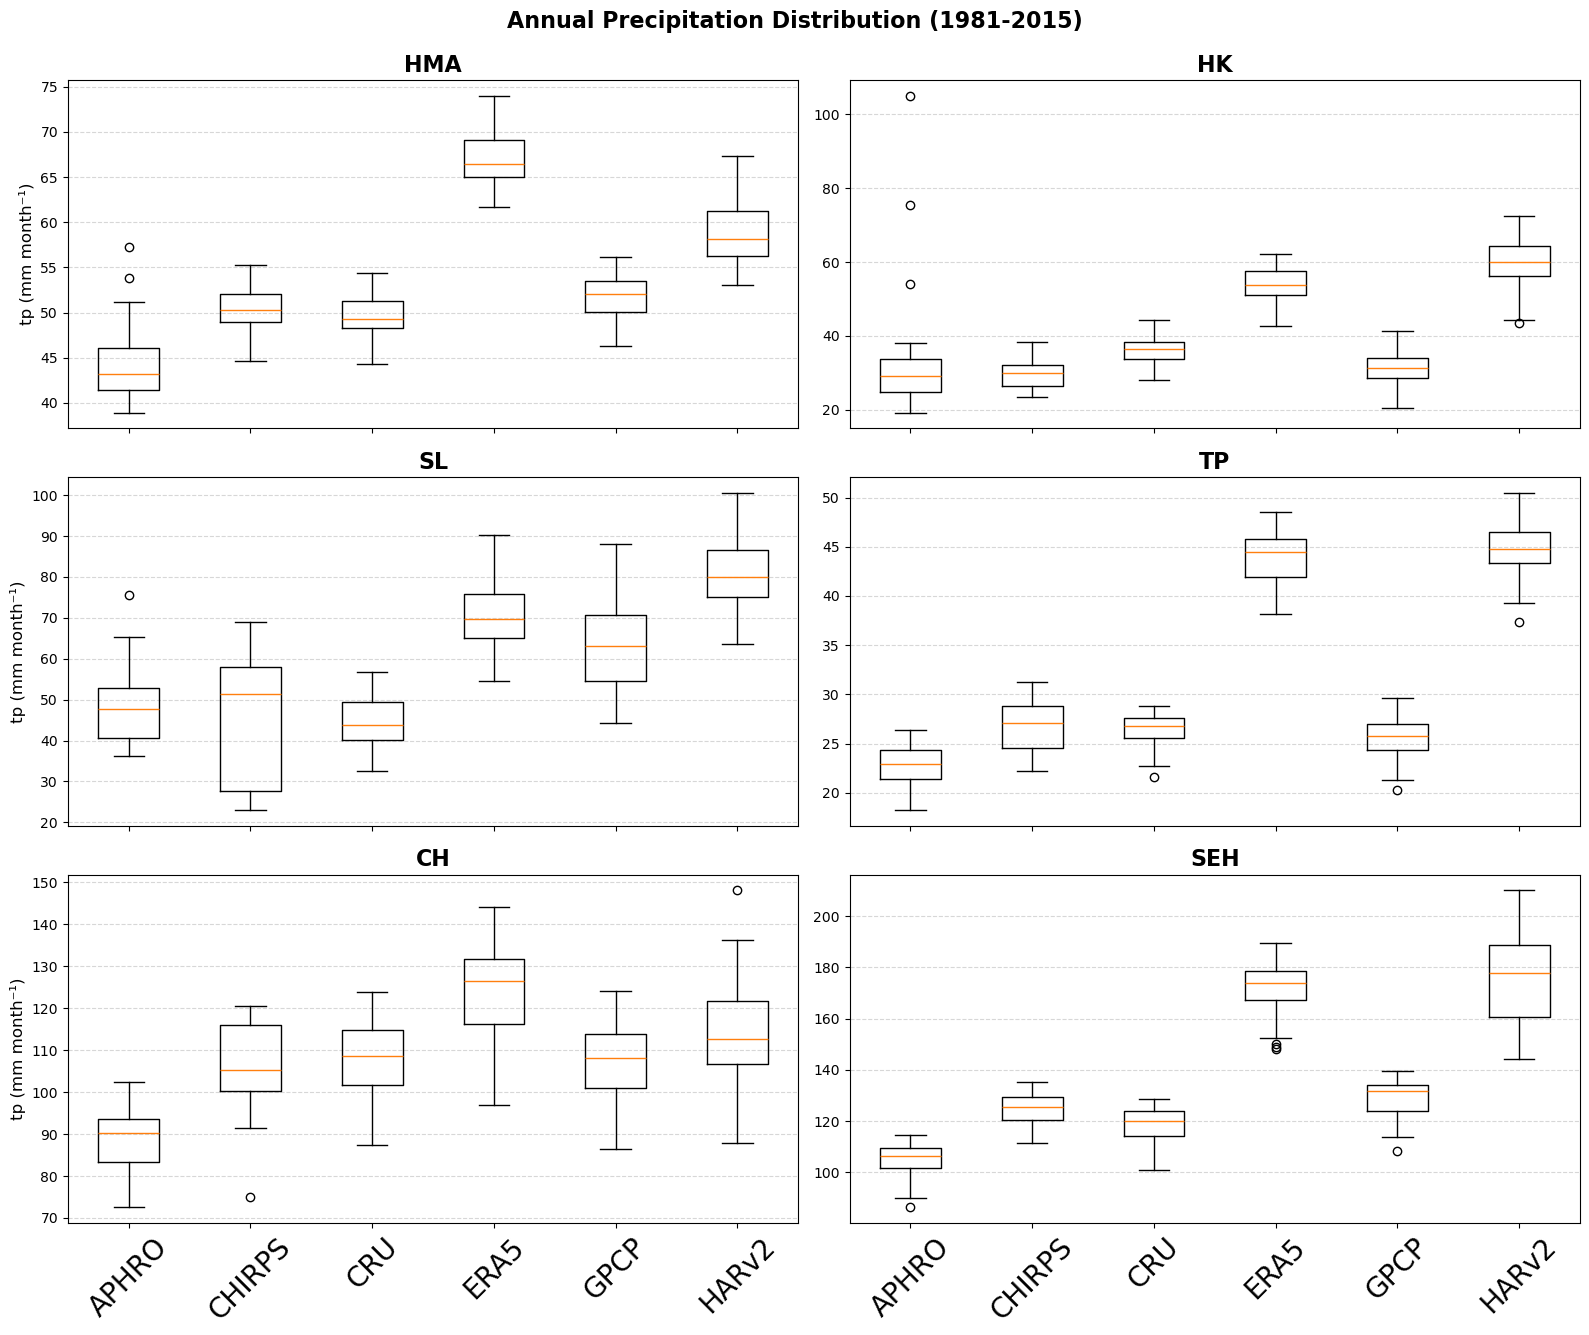

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(16,14))
axes = axes.flatten()

for i, dom in enumerate(domains):
    ax = axes[i]

    data_to_plot = []
    labels_to_plot = []

    for model in models:
        da = tp_datasets[model][dom]['tp']
        data_to_plot.append(da.values)
        labels_to_plot.append(model)

    # créer le boxplot
    bp = ax.boxplot(data_to_plot, tick_labels=labels_to_plot, patch_artist=False)

    # axes et style
    if i in [0, 2, 4]:
        ax.set_ylabel('tp (mm month⁻¹)', fontsize=12)
    if i in [4, 5]:
        ax.tick_params(labelbottom=True)
        ax.tick_params(axis='x', labelsize=20)
    if i in [0,1,2,3]:
        ax.tick_params(labelbottom=False)

    ax.set_title(dom, fontsize=16, weight='bold')
    ax.grid(True, linestyle='--', alpha=0.5, axis='y')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle(f'Annual Precipitation Distribution ({iyear}-{fyear})', fontsize=16, weight='bold')
plt.tight_layout(rect=[0,0.03,1,0.95])
fig.subplots_adjust(top=0.93) 
plt.show()

# Trend plot

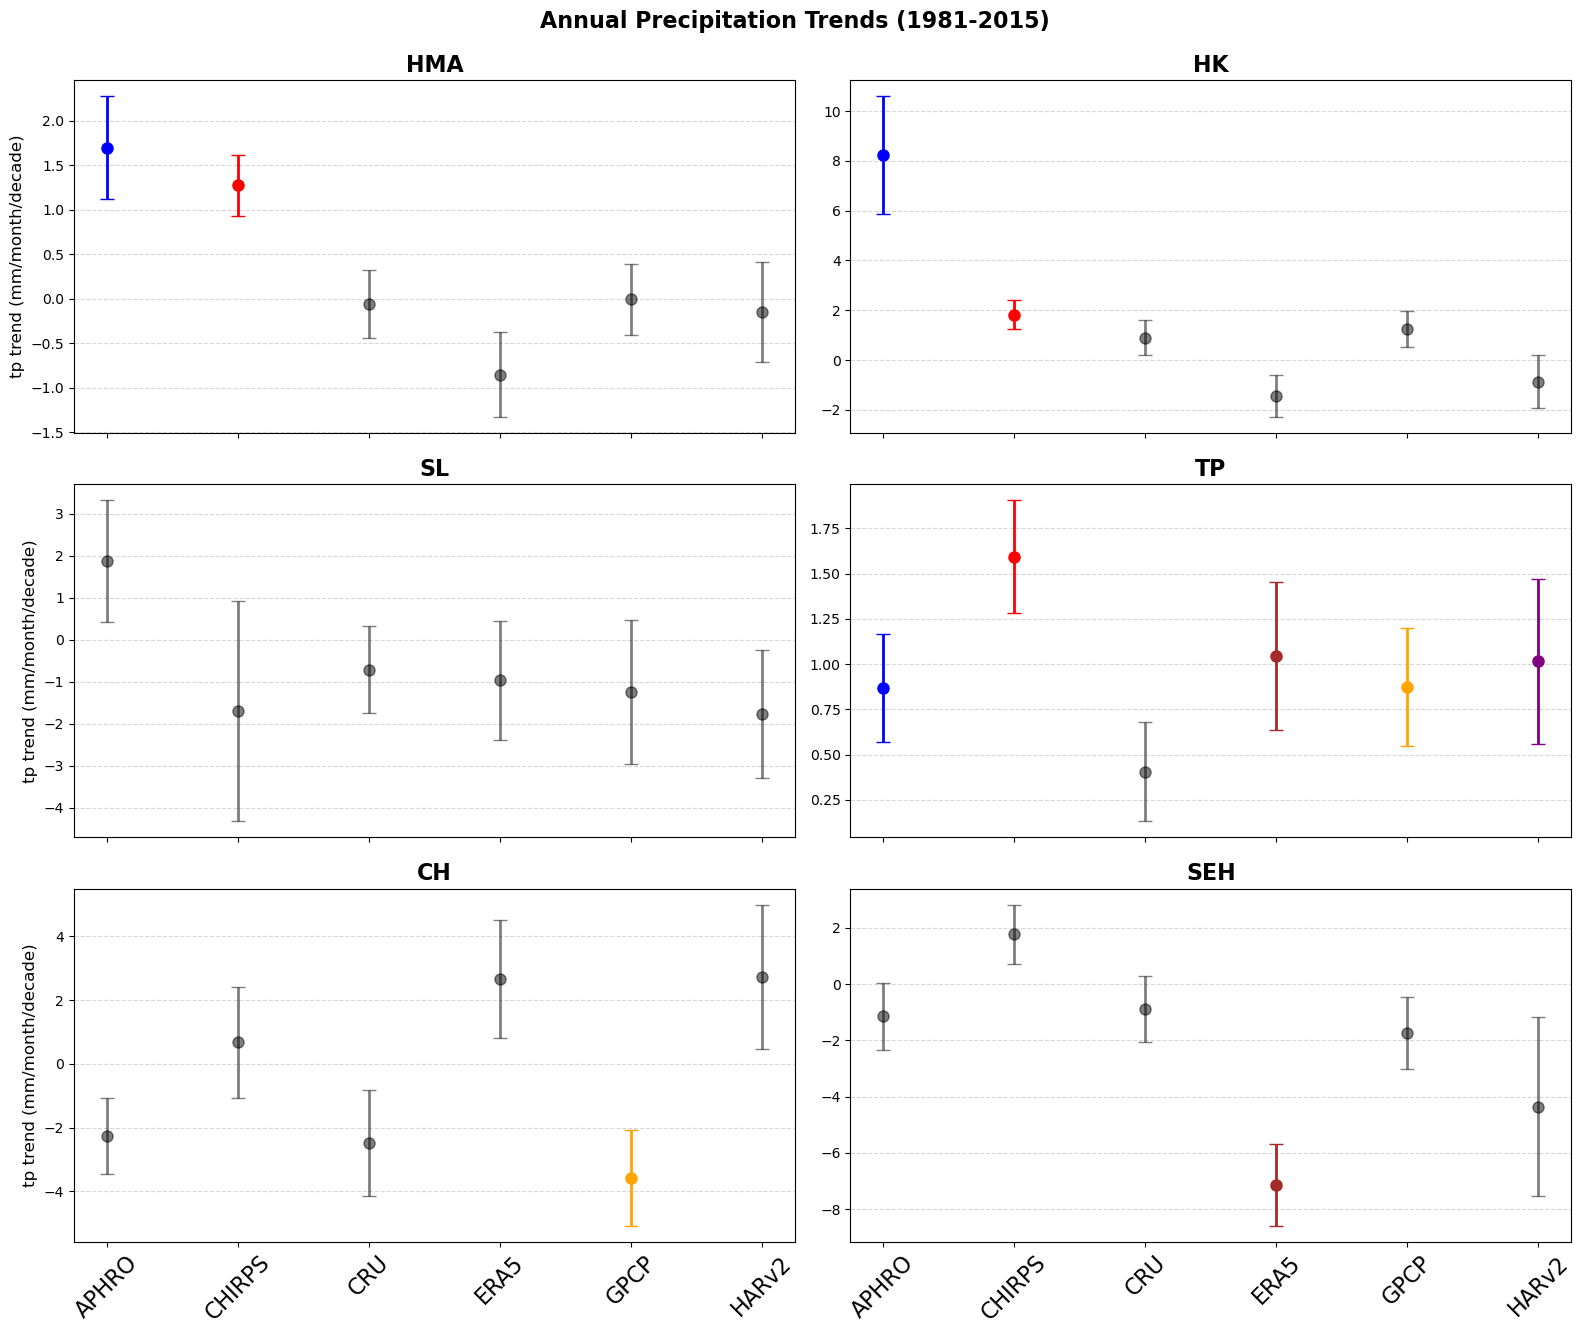

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(16,14))
axes = axes.flatten()

colors = {'APHRO':'blue', 'GPCP':'orange', 'CRU':'green',
          'CHIRPS':'red', 'HARv2':'purple', 'ERA5':'brown'}

for i, dom in enumerate(domains):
    ax = axes[i]

    x = range(1, len(models)+1)
    slopes = []
    errors = []

    for xi, model in zip(x, models):
        df = stats_datasets[model][dom]
        slope = df.loc[df['stat']=='slope', 'value'].values[0] *10
        std_err = df.loc[df['stat']=='std_err', 'value'].values[0] *10
        p_value = df.loc[df['stat']=='p_value', 'value'].values[0]

        if p_value <= 0.05:
            # plot point + barre d'erreur
            ax.errorbar(xi, slope, yerr=std_err, fmt='o', color=colors[model],
                        ecolor=colors[model], elinewidth=2, capsize=5, markersize=8)
        else:
            ax.errorbar(xi, slope, yerr=std_err, fmt='o', color='black',
                        ecolor='black', elinewidth=2, capsize=5, markersize=8, alpha=0.5)

    # axes et style
    if i in [0, 2, 4]:
        ax.set_ylabel('tp trend (mm/month/decade)', fontsize=12)
    if i in [4, 5]:
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=45, fontsize=16)
    if i in [0,1,2,3]:
        ax.tick_params(labelbottom=False)

    ax.set_title(dom, fontsize=16, weight='bold')
    ax.grid(True, linestyle='--', alpha=0.5, axis='y')

fig.suptitle(f'Annual Precipitation Trends ({iyear}-{fyear})', fontsize=16, weight='bold')
plt.tight_layout(rect=[0,0.03,1,0.95])
fig.subplots_adjust(top=0.93)
plt.show()

# All period for every dataset

In [7]:
iyear = 1891
fyear = 2025
models = ['APHRO','CHIRPS','CRU','ERA5','GPCP','HARv2']
domains = ['HMA','HK','SL','TP','CH','SEH']

In [8]:
tp_datasets = {}
stats_datasets = {}

path = '/bettik/PROJECTS/pr-regional-climate/bricej/results/timeseries/'

model=models[0]
tp_datasets[model] = {}
stats_datasets[model] = {}
for domain in domains:
    tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1951-2015_{model}.csv')
    stats_datasets[model][domain] = pd.read_csv(path + f'stats_tp_annual_{domain}_1951-2015_{model}.csv')

model=models[4]
tp_datasets[model] = {}
stats_datasets[model] = {}
for domain in domains:
    tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1891-2019_{model}.csv')
    stats_datasets[model][domain] = pd.read_csv(path + f'stats_tp_annual_{domain}_1891-2019_{model}.csv')

model=models[2]
tp_datasets[model] = {}
stats_datasets[model] = {}
for domain in domains:
    tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1901-2020_{model}.csv')
    stats_datasets[model][domain] = pd.read_csv(path + f'stats_tp_annual_{domain}_1901-2020_{model}.csv')

model=models[1]
tp_datasets[model] = {}
stats_datasets[model] = {}
for domain in domains:
    tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1981-2025_{model}.csv')
    stats_datasets[model][domain] = pd.read_csv(path + f'stats_tp_annual_{domain}_1981-2025_{model}.csv')

model=models[5]
tp_datasets[model] = {}
stats_datasets[model] = {}
for domain in domains:
    tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1980-2023_{model}.csv')
    stats_datasets[model][domain] = pd.read_csv(path + f'stats_tp_annual_{domain}_1980-2023_{model}.csv')

model=models[3]
tp_datasets[model] = {}
stats_datasets[model] = {}
for domain in domains:
    tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1940-2025_{model}.csv')
    stats_datasets[model][domain] = pd.read_csv(path + f'stats_tp_annual_{domain}_1940-2025_{model}.csv')

,HMA,HK,SL,TP,CH,SEH
APHRO,0.38,2.42,-0.79,0.19,-0.23,-1.03
CHIRPS,0.06,1.05,0.79,0.40,-2.17,-2.30
CRU,-0.04,0.60,-0.03,0.13,-0.84,-0.70
ERA5,-0.34,0.74,-0.56,0.34,-0.70,-1.76
GPCP,0.05,0.32,0.05,0.19,-0.66,-0.28
HARv2,-0.13,-1.83,-0.80,1.13,3.50,-4.32


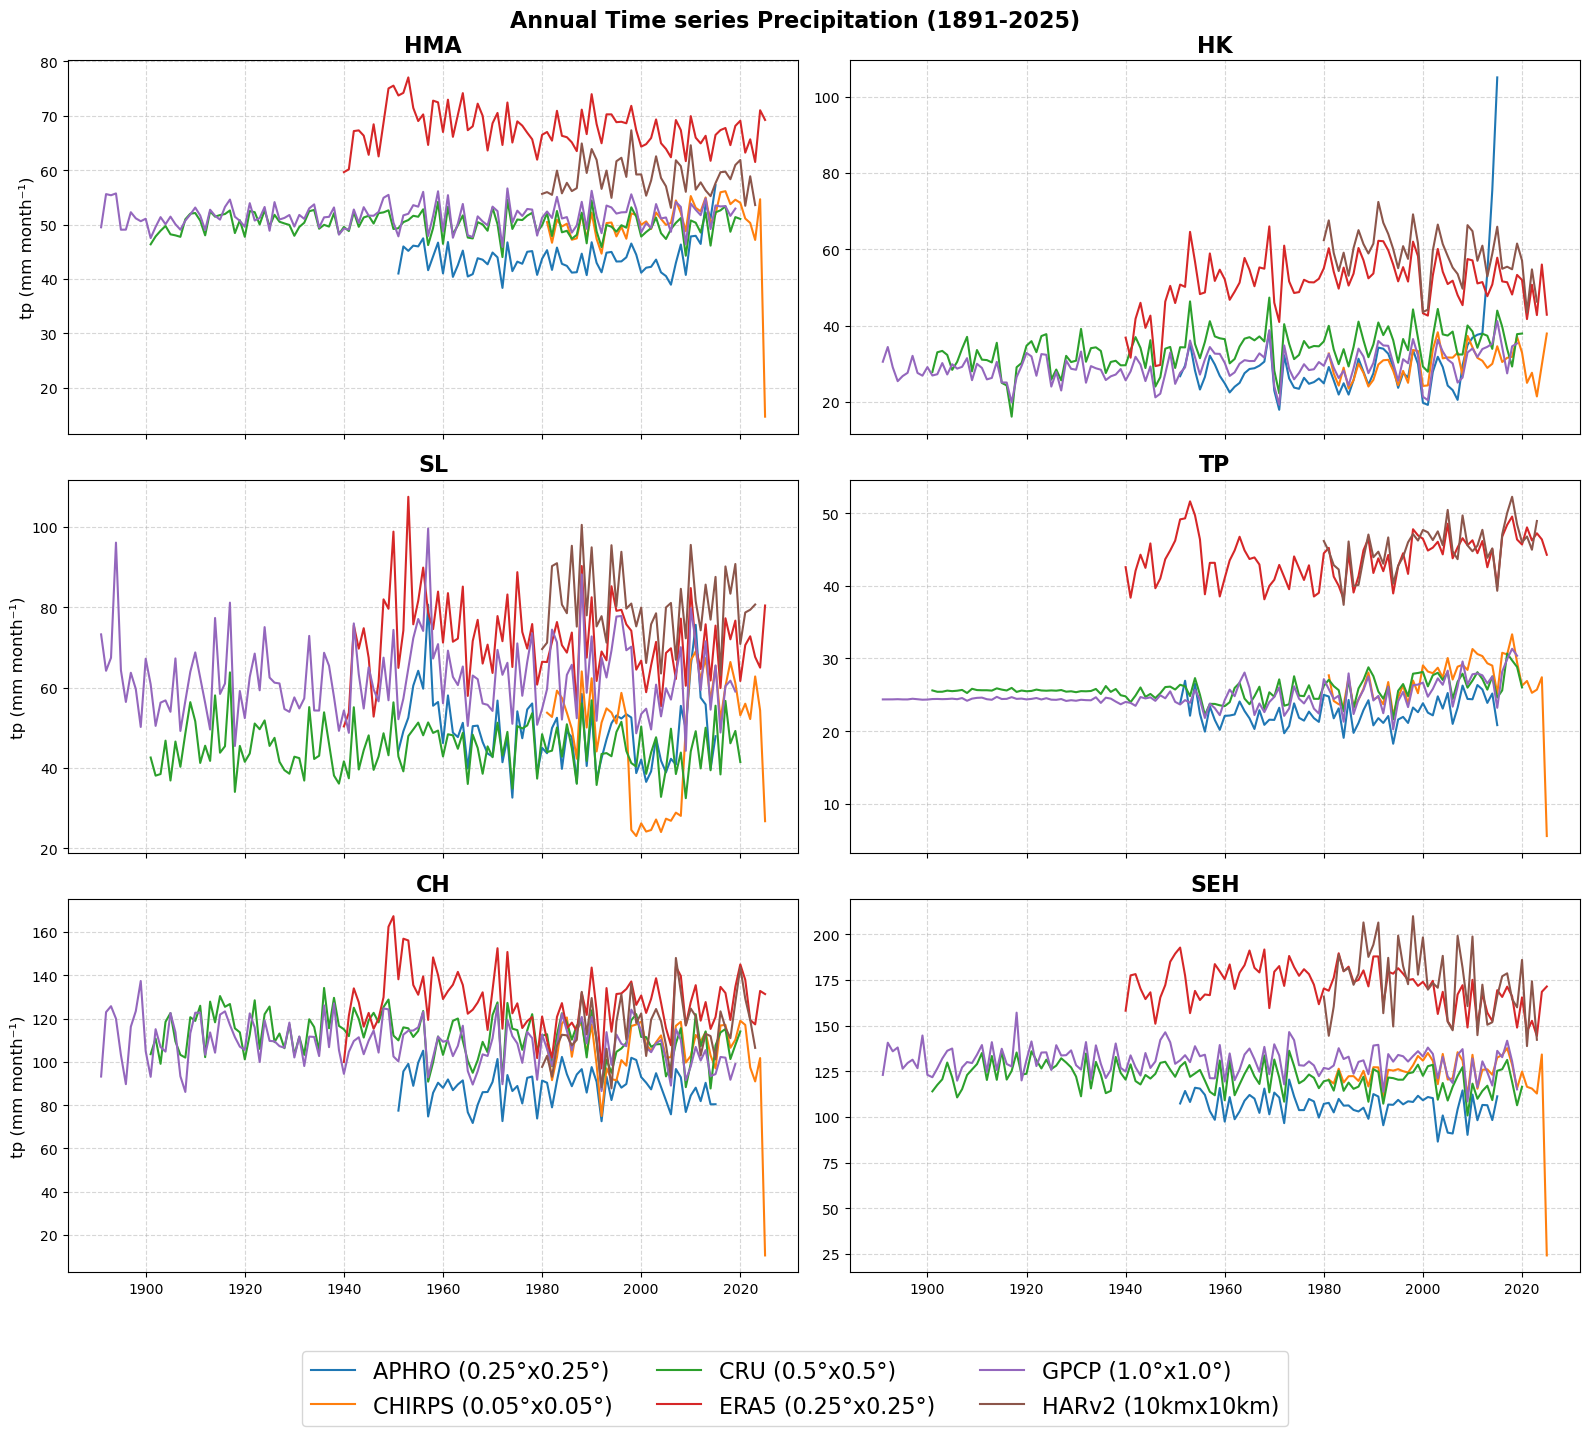

In [9]:
resolutions = {'APHRO': '0.25°x0.25°',
               'GPCP': '1.0°x1.0°',
               'CRU': '0.5°x0.5°',
               'CHIRPS': '0.05°x0.05°',
               'HARv2': '10kmx10km',
               'ERA5': '0.25°x0.25°'}

#============== tableau des p-values ==========================

table = pd.DataFrame(index=models, columns=domains)
pvals = pd.DataFrame(index=models, columns=domains)

for model in models:
    for dom in domains:

        df = stats_datasets[model][dom]

        slope = df.loc[df['stat']=='slope','value'].values[0] * 10
        pval  = df.loc[df['stat']=='p_value','value'].values[0]

        table.loc[model, dom] = slope
        pvals.loc[model, dom] = pval

def bold_sig(val, p):
    if p < 0.05:
        return 'font-weight: bold'
    return ''

styled_table = table.style.apply(
    lambda x: [bold_sig(v, pvals.loc[x.name, col]) for col, v in x.items()],
    axis=1
).format("{:.2f}")

display(styled_table)

# ====================== plot time series ========================

fig, axes = plt.subplots(3, 2, figsize=(16,14))
axes = axes.flatten()

for i, dom in enumerate(domains):

    ax = axes[i]

    for model in models:
        da = tp_datasets[model][dom]
        ax.plot(da['year'], da['tp'], linestyle='-', label=f'{model} ({resolutions[model]})', linewidth=1.5)

    ax.set_title(dom, fontsize=16, weight="bold")
    
    if i in [0, 2, 4]:  # colonne gauche
        ax.set_ylabel('tp (mm month⁻¹)', fontsize=12)
    if i in [4, 5]:  # ligne du bas
        ax.tick_params(labelbottom=True)
    if i in [0,1,2,3]:
        ax.tick_params(labelbottom=False)
    
    ax.grid(True, linestyle='--', alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)
fig.suptitle(f'Annual Time series Precipitation (1891-2025)', fontsize=16, weight='bold')

plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

# HMA domain

,HMA,HK,SL,TP,CH,SEH
APHRO,0.38,nan,nan,nan,nan,nan
CHIRPS,0.06,nan,nan,nan,nan,nan
CRU,-0.04,nan,nan,nan,nan,nan
ERA5,-0.34,nan,nan,nan,nan,nan
GPCP,0.05,nan,nan,nan,nan,nan
HARv2,-0.13,nan,nan,nan,nan,nan


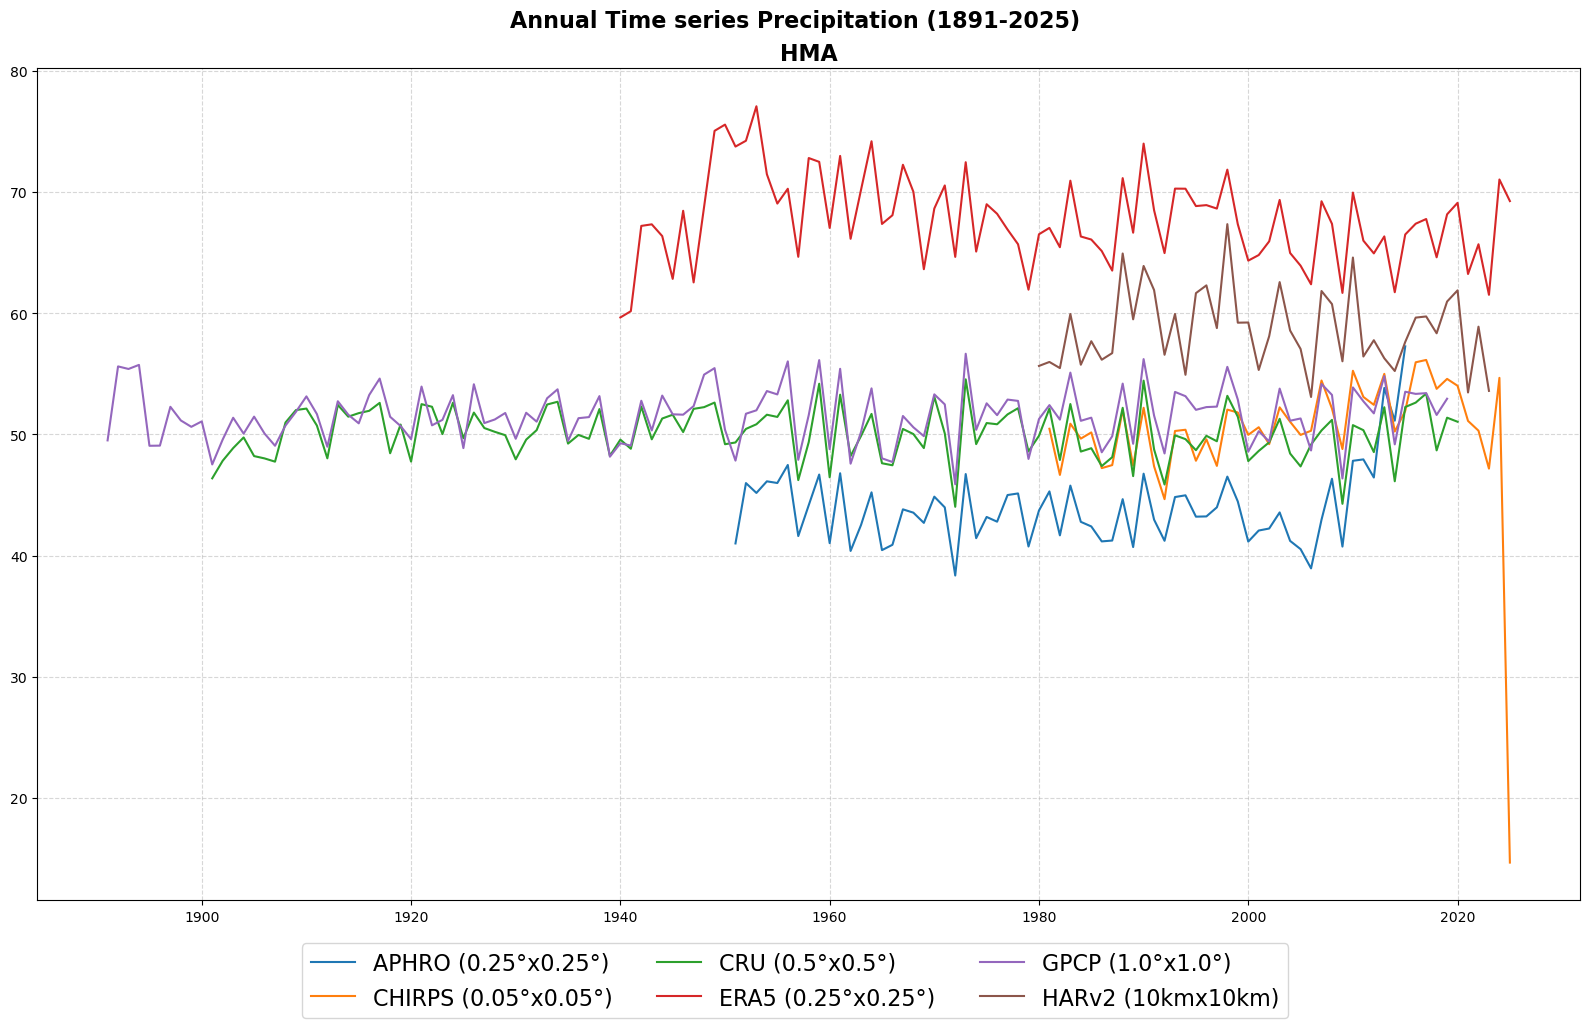

In [10]:
resolutions = {'APHRO': '0.25°x0.25°',
               'GPCP': '1.0°x1.0°',
               'CRU': '0.5°x0.5°',
               'CHIRPS': '0.05°x0.05°',
               'HARv2': '10kmx10km',
               'ERA5': '0.25°x0.25°'}

dom='HMA'

#============== tableau des p-values ==========================

table = pd.DataFrame(index=models, columns=domains)
pvals = pd.DataFrame(index=models, columns=domains)

for model in models:

    df = stats_datasets[model][dom]

    slope = df.loc[df['stat']=='slope','value'].values[0] * 10
    pval  = df.loc[df['stat']=='p_value','value'].values[0]

    table.loc[model, dom] = slope
    pvals.loc[model, dom] = pval

def bold_sig(val, p):
    if p < 0.05:
        return 'font-weight: bold'
    return ''

styled_table = table.style.apply(
    lambda x: [bold_sig(v, pvals.loc[x.name, col]) for col, v in x.items()],
    axis=1
).format("{:.2f}")

display(styled_table)

# ====================== plot time series ========================

fig, ax = plt.subplots(figsize=(16,10))
axes = axes.flatten()

for model in models:
    da = tp_datasets[model][dom]
    ax.plot(da['year'], da['tp'], linestyle='-', label=f'{model} ({resolutions[model]})', linewidth=1.5)

ax.set_title(dom, fontsize=16, weight="bold")
    
if i in [0, 2, 4]:  # colonne gauche
    ax.set_ylabel('tp (mm month⁻¹)', fontsize=12)
if i in [4, 5]:  # ligne du bas
    ax.tick_params(labelbottom=True)
if i in [0,1,2,3]:
    ax.tick_params(labelbottom=False)
    
ax.grid(True, linestyle='--', alpha=0.5)

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)
fig.suptitle(f'Annual Time series Precipitation (1891-2025)', fontsize=16, weight='bold')

plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

## Changing the period : 

In [11]:
tp_datasets = {}
stats_datasets = {}

domain = 'HMA'

path = '/bettik/PROJECTS/pr-regional-climate/bricej/results/timeseries/'

model=models[0]
tp_datasets[model] = {}
stats_datasets[model] = {}

tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1951-2005_{model}.csv')
stats_datasets[model][domain] = pd.read_csv(path + f'stats_tp_annual_{domain}_1951-2005_{model}.csv')

model=models[4]
tp_datasets[model] = {}
stats_datasets[model] = {}
tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1891-2019_{model}.csv')
stats_datasets[model][domain] = pd.read_csv(path + f'stats_tp_annual_{domain}_1891-2019_{model}.csv')

model=models[2]
tp_datasets[model] = {}
stats_datasets[model] = {}
tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1901-2020_{model}.csv')
stats_datasets[model][domain] = pd.read_csv(path + f'stats_tp_annual_{domain}_1901-2020_{model}.csv')

model=models[1]
tp_datasets[model] = {}
stats_datasets[model] = {}
tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1981-2024_{model}.csv')
stats_datasets[model][domain] = pd.read_csv(path + f'stats_tp_annual_{domain}_1981-2024_{model}.csv')

model=models[5]
tp_datasets[model] = {}
stats_datasets[model] = {}
tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1980-2023_{model}.csv')
stats_datasets[model][domain] = pd.read_csv(path + f'stats_tp_annual_{domain}_1980-2023_{model}.csv')

model=models[3]
tp_datasets[model] = {}
stats_datasets[model] = {}
tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1960-2025_{model}.csv')
stats_datasets[model][domain] = pd.read_csv(path + f'stats_tp_annual_{domain}_1960-2025_{model}.csv')

,trend,std error,mean,std
APHRO,-0.26,0.02,43.38,2.12
CHIRPS,1.19,0.03,50.90,2.70
CRU,-0.04,0.01,50.12,2.08
ERA5,-0.45,0.02,67.33,3.01
GPCP,0.05,0.01,51.59,2.25
HARv2,-0.13,0.04,58.66,3.22


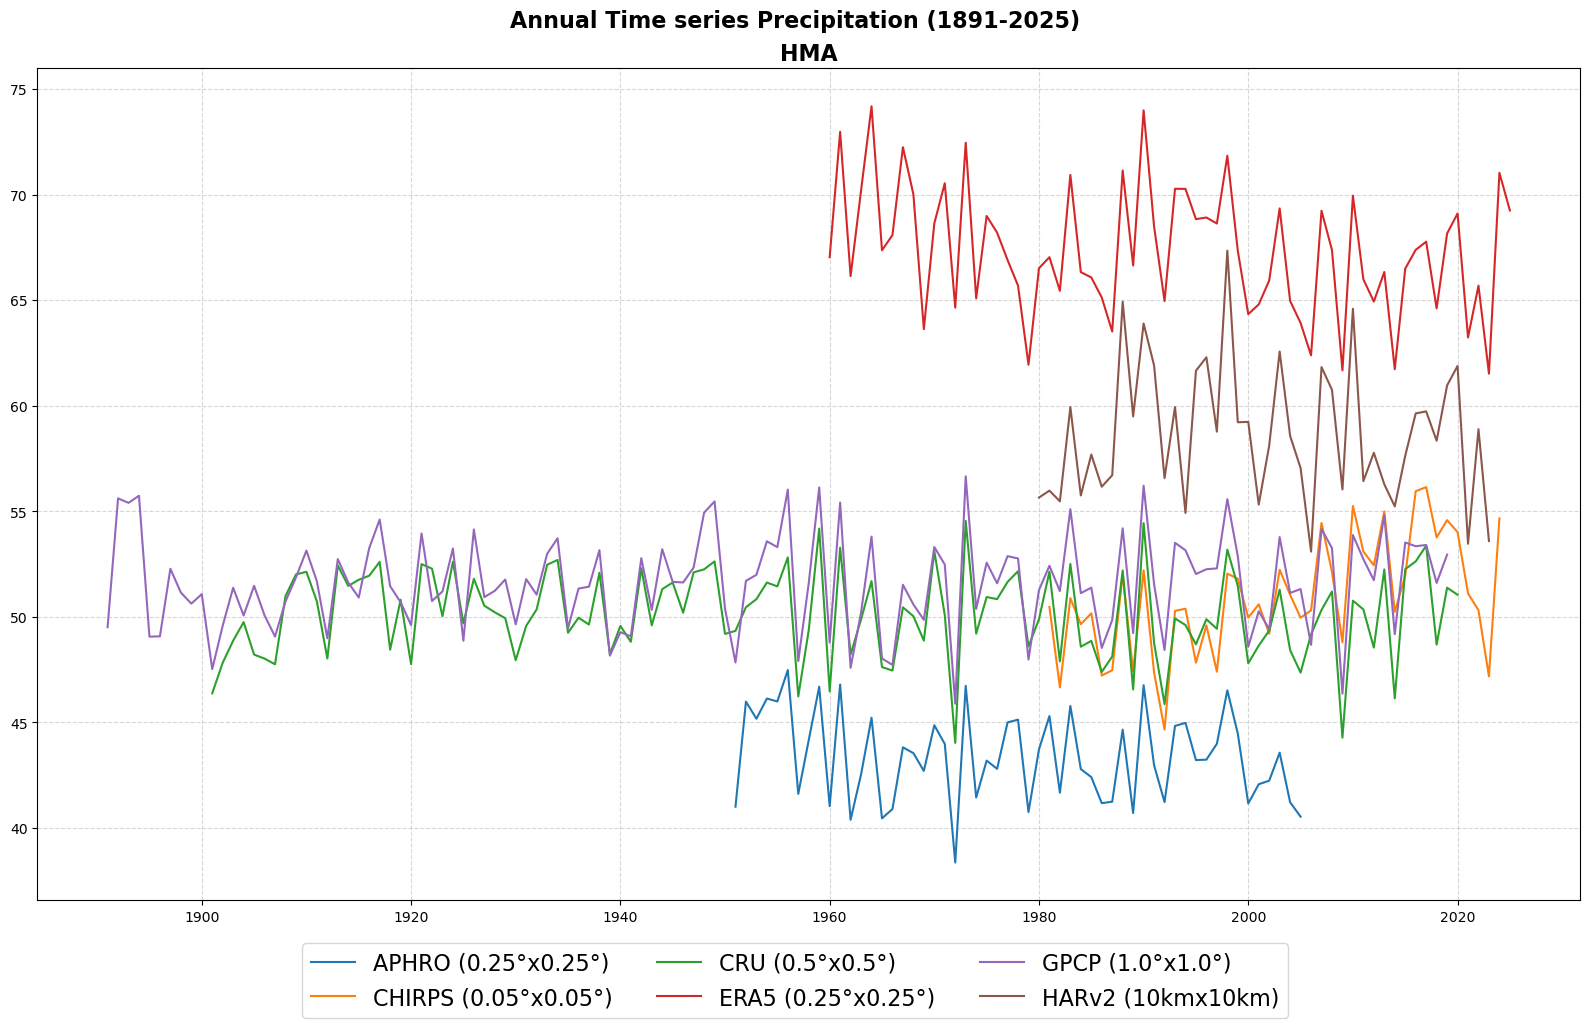

In [12]:
resolutions = {'APHRO': '0.25°x0.25°',
               'GPCP': '1.0°x1.0°',
               'CRU': '0.5°x0.5°',
               'CHIRPS': '0.05°x0.05°',
               'HARv2': '10kmx10km',
               'ERA5': '0.25°x0.25°'}

dom='HMA'

#============== tableau des p-values ==========================

cols = ['trend', 'std error', 'mean', 'std']
table = pd.DataFrame(index=models, columns=cols)
pvals = pd.Series(index=models)

for model in models:
    df = stats_datasets[model][dom]

    table.loc[model, 'trend'] = df.loc[df['stat']=='slope','value'].values[0] * 10
    table.loc[model, 'mean']  = df.loc[df['stat']=='mean','value'].values[0]
    table.loc[model, 'std']   = df.loc[df['stat']=='std','value'].values[0]
    table.loc[model, 'std error'] = df.loc[df['stat']=='std_err','value'].values[0]

    pvals.loc[model] = df.loc[df['stat']=='p_value','value'].values[0]

def bold_sig(val, p):
    if p < 0.05:
        return 'font-weight: bold'
    return ''

styled_table = table.style.apply(
    lambda x: [
        bold_sig(v, pvals.loc[x.name]) if col == 'trend' else ''
        for col, v in x.items()
    ],
    axis=1
).format("{:.2f}")

display(styled_table)

# ====================== plot time series ========================

fig, ax = plt.subplots(figsize=(16,10))
axes = axes.flatten()

for model in models:
    da = tp_datasets[model][dom]
    ax.plot(da['year'], da['tp'], linestyle='-', label=f'{model} ({resolutions[model]})', linewidth=1.5)

ax.set_title(dom, fontsize=16, weight="bold")
    
if i in [0, 2, 4]:  # colonne gauche
    ax.set_ylabel('tp (mm month⁻¹)', fontsize=12)
if i in [4, 5]:  # ligne du bas
    ax.tick_params(labelbottom=True)
if i in [0,1,2,3]:
    ax.tick_params(labelbottom=False)
    
ax.grid(True, linestyle='--', alpha=0.5)

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)
fig.suptitle(f'Annual Time series Precipitation (1891-2025)', fontsize=16, weight='bold')

plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

In [13]:
tp_datasets = {}
stats_datasets = {}

domain = 'HMA'

path = '/bettik/PROJECTS/pr-regional-climate/bricej/results/timeseries/'

model=models[0]
tp_datasets[model] = {}
stats_datasets[model] = {}

tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1951-2015_{model}.csv')
stats_datasets[model][domain] = pd.read_csv(path + f'stats_tp_annual_{domain}_1951-2015_{model}.csv')

model=models[4]
tp_datasets[model] = {}
stats_datasets[model] = {}
tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1891-2019_{model}.csv')
stats_datasets[model][domain] = pd.read_csv(path + f'stats_tp_annual_{domain}_1891-2019_{model}.csv')

model=models[2]
tp_datasets[model] = {}
stats_datasets[model] = {}
tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1901-2020_{model}.csv')
stats_datasets[model][domain] = pd.read_csv(path + f'stats_tp_annual_{domain}_1901-2020_{model}.csv')

model=models[1]
tp_datasets[model] = {}
stats_datasets[model] = {}
tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1981-2024_{model}.csv')
stats_datasets[model][domain] = pd.read_csv(path + f'stats_tp_annual_{domain}_1981-2024_{model}.csv')

model=models[5]
tp_datasets[model] = {}
stats_datasets[model] = {}
tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1980-2023_{model}.csv')
stats_datasets[model][domain] = pd.read_csv(path + f'stats_tp_annual_{domain}_1980-2023_{model}.csv')

model=models[3]
tp_datasets[model] = {}
stats_datasets[model] = {}
tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1940-2025_{model}.csv')
stats_datasets[model][domain] = pd.read_csv(path + f'stats_tp_annual_{domain}_1940-2025_{model}.csv')

,trend,std error,mean,std
APHRO,0.38,0.02,43.99,3.21
CHIRPS,1.19,0.03,50.90,2.70
CRU,-0.04,0.01,50.12,2.08
ERA5,-0.34,0.02,67.72,3.65
GPCP,0.05,0.01,51.59,2.25
HARv2,-0.13,0.04,58.66,3.22


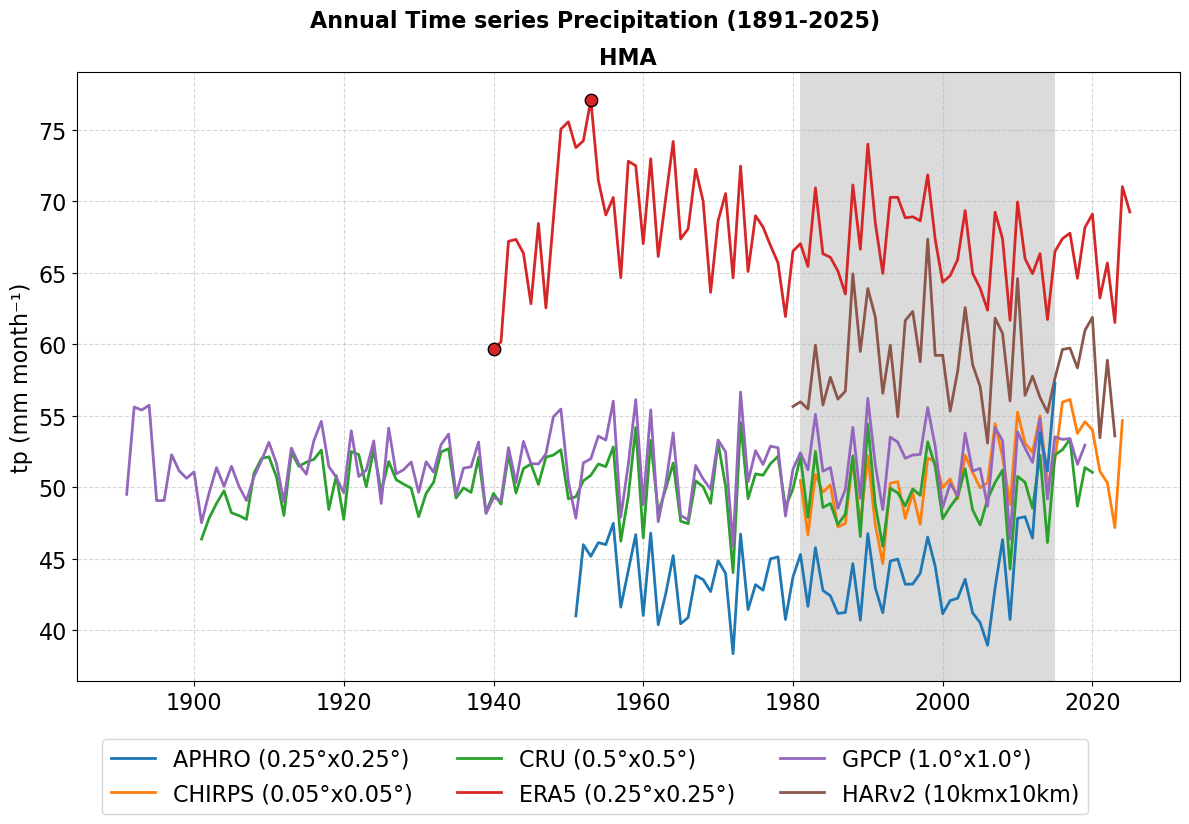

In [14]:
resolutions = {'APHRO': '0.25°x0.25°',
               'GPCP': '1.0°x1.0°',
               'CRU': '0.5°x0.5°',
               'CHIRPS': '0.05°x0.05°',
               'HARv2': '10kmx10km',
               'ERA5': '0.25°x0.25°'}

dom='HMA'

#============== tableau des p-values ==========================

cols = ['trend', 'std error', 'mean', 'std']
table = pd.DataFrame(index=models, columns=cols)
pvals = pd.Series(index=models)

for model in models:
    df = stats_datasets[model][dom]

    table.loc[model, 'trend'] = df.loc[df['stat']=='slope','value'].values[0] * 10
    table.loc[model, 'mean']  = df.loc[df['stat']=='mean','value'].values[0]
    table.loc[model, 'std']   = df.loc[df['stat']=='std','value'].values[0]
    table.loc[model, 'std error'] = df.loc[df['stat']=='std_err','value'].values[0]

    pvals.loc[model] = df.loc[df['stat']=='p_value','value'].values[0]

def bold_sig(val, p):
    if p < 0.05:
        return 'font-weight: bold'
    return ''

styled_table = table.style.apply(
    lambda x: [
        bold_sig(v, pvals.loc[x.name]) if col == 'trend' else ''
        for col, v in x.items()
    ],
    axis=1
).format("{:.2f}")

display(styled_table)

# ====================== plot time series ========================

fig, ax = plt.subplots(figsize=(12,8))
axes = axes.flatten()

for model in models:
    da = tp_datasets[model][dom]

    if model == 'APHRO':
        ax.plot(da['year'], da['tp'], linestyle='-', label=f'{model} ({resolutions[model]})', linewidth=2, zorder=10)
    else:
        ax.plot(da['year'], da['tp'], linestyle='-', label=f'{model} ({resolutions[model]})', linewidth=2, zorder=2)

    if model == 'ERA5':
        imax = np.argmax(da['tp'])
        imin = np.argmin(da['tp'])
        ax.scatter(da['year'][imax], da['tp'][imax], color='tab:red', s=80, edgecolor='black', zorder=10)
        ax.scatter(da['year'][imin], da['tp'][imin], color='tab:red', s=80, edgecolor='black', zorder=10)

ax.set_title(dom, fontsize=16, weight="bold")
ax.set_ylabel('tp (mm month⁻¹)', fontsize=16)


ax.tick_params(labelbottom=True, labelsize=16)
    
ax.grid(True, linestyle='--', alpha=0.5)

ax.axvspan(1981,2015,color='lightgray',alpha=0.8,zorder=0,ec=None)

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)
fig.suptitle(f'Annual Time series Precipitation (1891-2025)', fontsize=16, weight='bold')

plt.tight_layout(rect=[0,0.08,1,1]) # [left, bottom, right, top]
plt.show()

# Cohérence 

In [15]:
for model in models:
    tp_datasets[model]['HMA'] = tp_datasets[model]['HMA'][tp_datasets[model]['HMA']['year'].between(1981, 2010)]

In [16]:
domain = 'HMA'
ref_model = 'ERA5'

coherence = pd.DataFrame(index=models, columns=['coherence'], dtype=float)

# référence
ref_df = tp_datasets[ref_model][domain][['year', 'tp']]

for model in models:
    df = tp_datasets[model][domain][['year', 'tp']]

    # merge sur les années communes
    merged = pd.merge(
        ref_df,
        df,
        on='year',
        suffixes=('_ref', '_model')
    ).dropna()
    
    # corrélation (Pearson)
    corr = merged['tp_ref'].corr(merged['tp_model'])

    coherence.loc[model, 'coherence'] = corr

display(coherence.style.format("{:.2f}"))

,coherence
APHRO,0.84
CHIRPS,0.46
CRU,0.80
ERA5,1.00
GPCP,0.90
HARv2,0.75


In [17]:
for model in models:
    tp_datasets[model]['HMA'] = tp_datasets[model]['HMA'][tp_datasets[model]['HMA']['year'].between(1981, 2019)]

In [18]:
domain = 'HMA'
ref_model = 'ERA5'

coherence = pd.DataFrame(index=models, columns=['coherence'], dtype=float)

# référence
ref_df = tp_datasets[ref_model][domain][['year', 'tp']]

for model in models:
    df = tp_datasets[model][domain][['year', 'tp']]

    # merge sur les années communes
    merged = pd.merge(
        ref_df,
        df,
        on='year',
        suffixes=('_ref', '_model')
    ).dropna()
    
    # corrélation (Pearson)
    corr = merged['tp_ref'].corr(merged['tp_model'])

    coherence.loc[model, 'coherence'] = corr

display(coherence.style.format("{:.2f}"))

,coherence
APHRO,0.84
CHIRPS,0.46
CRU,0.80
ERA5,1.00
GPCP,0.90
HARv2,0.75


In [19]:
for model in models:
    tp_datasets[model]['HMA'] = tp_datasets[model]['HMA'][tp_datasets[model]['HMA']['year'].between(1981, 2015)]

In [20]:
domain = 'HMA'
ref_model = 'ERA5'

coherence = pd.DataFrame(index=models, columns=['coherence'], dtype=float)

# référence
ref_df = tp_datasets[ref_model][domain][['year', 'tp']]

for model in models:
    df = tp_datasets[model][domain][['year', 'tp']]

    # merge sur les années communes
    merged = pd.merge(
        ref_df,
        df,
        on='year',
        suffixes=('_ref', '_model')
    ).dropna()
    
    # corrélation (Pearson)
    corr = merged['tp_ref'].corr(merged['tp_model'])

    coherence.loc[model, 'coherence'] = corr

display(coherence.style.format("{:.2f}"))

,coherence
APHRO,0.84
CHIRPS,0.46
CRU,0.80
ERA5,1.00
GPCP,0.90
HARv2,0.75


# RMSE with ERA5

In [21]:
for model in models:
    tp_datasets[model]['HMA'] = tp_datasets[model]['HMA'][tp_datasets[model]['HMA']['year'].between(1981, 2015)].reset_index(drop=True)

In [22]:
era5 = tp_datasets['ERA5']['HMA'][['year', 'tp']]
rmse = pd.DataFrame(index=models, columns=['rmse'], dtype=float)

for model in models:
    df = tp_datasets[model]['HMA'][['year', 'tp']]

    diff = (df['tp'] - era5['tp'])**2
    sum_diff = np.sum(diff)
    rmse_model = np.sqrt(sum_diff/35)

    rmse.loc[model,'rmse'] = rmse_model

In [23]:
display(rmse.style.format("{:.2f}"))

,rmse
APHRO,22.40
CHIRPS,16.26
CRU,16.61
ERA5,0.00
GPCP,14.49
HARv2,7.81


In [24]:
era5 = tp_datasets['ERA5']['HMA'][['year', 'tp']]
bias = pd.DataFrame(index=models, columns=['bias'], dtype=float)

for model in models:
    df = tp_datasets[model]['HMA'][['year', 'tp']]

    diff = df['tp'] - era5['tp']
    mean_diff = np.mean(diff)

    bias.loc[model,'bias'] = mean_diff

In [25]:
display(bias.style.format("{:.2f}"))

,bias
APHRO,-24.14
CHIRPS,-17.35
CRU,-17.86
ERA5,0.00
GPCP,-15.60
HARv2,-8.13
